In [73]:
import torchvision
from torchvision import transforms
import torch
from torch.utils.data import DataLoader, random_split
from torch import nn
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import copy
import seaborn as sns

torch.manual_seed(42)

Here we select the device to be used for training. We use a GPU if available.

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Download the FashionMNIST Dataset using `torchvision`, transform the dataset to tensor and normalize it from [0,1]

In [12]:
transform = transforms.ToTensor()  # transformer to tensor and normalizes to [0, 1]

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, 
                                                    download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, 
                                                   download=True, transform=transform)

Reserve 10% of the training dataset for the validation dataset.

In [13]:
# Reserve 10% of training set as validation (as per your assignment)
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

We create a CustomCNN Model below.

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, ):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1) # output dims (32, 28, 28)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2) # output dims (32, 14, 14)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) # output dims (64, 14, 14)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2) # output dims (64, 7, 7)
        self.fc1 = nn.Linear(in_features=64*7*7, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=10)
        
    def forward(self, X):
        X = torch.relu(self.conv1(X))
        X = self.maxpool1(X)
        X = torch.relu(self.conv2(X))
        X = torch.flatten(self.maxpool2(X), start_dim=1)
        X = torch.relu(self.fc1(X))
        return self.fc2(X)

In [15]:
torch.backends.cudnn.enabled = False

In [16]:
model = CustomCNN().float().to(device)

# hyper params
lr = 0.001
weight_decay=0.01
optim = torch.optim.AdamW(model.parameters(), lr, weight_decay=weight_decay)
loss = nn.CrossEntropyLoss()
patience = 10

# statistics to save
train_avg_losses = []
train_accs = []

val_avg_losses = []
val_accs = []

# variables for training
curr_epoch = 1
best_val_loss = float('inf')
best_model = model
patience_counter = 0
while True:
    print(f"---- Epoch {curr_epoch} ----")
    model.train()
    train_loss = 0
    train_total = 0
    train_correct = 0
    for images, labels in train_loader:
        # transfer data to the compute device
        images, labels = images.to(device), labels.to(device)
        images, labels = images.float(), labels.long()
        # perform predictions
        output = model(images)
        l = loss(output, labels)
        
        # store data
        predictions = torch.argmax(output, dim=1)
        train_loss += l.item()
        train_total += labels.size(0) # keep track of the total dataset since you don't know the size of the last batch
        train_correct += (predictions == labels).sum().item()
        
        # apply backpropagtion
        optim.zero_grad()
        l.backward()
        optim.step()
    
    train_avg_losses.append(train_loss/len(train_loader))
    train_accs.append((train_correct/train_total)*100)

    print(f"Avg training loss: {train_avg_losses[-1]:.4f}")
    print(f"Training accuracy: {train_accs[-1]:.4f}%")

    val_loss = 0
    val_total = 0
    val_correct = 0
    model.eval()
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        images, labels = images.float(), labels.long()

        output = model(images)

        l = loss(output, labels)

        predictions = torch.argmax(output, dim=1)
        val_loss += l.item()
        val_total += labels.size(0)
        val_correct += (predictions == labels).sum().item()
    
    val_avg_losses.append(val_loss/len(val_loader))
    val_accs.append((val_correct/val_total)*100)

    print(f"Avg validation loss: {val_avg_losses[-1]:.4f}")
    print(f"Validation accuracy: {val_accs[-1]:.4f}%")
    
    if val_avg_losses[-1] < best_val_loss:
        best_val_loss = val_avg_losses[-1]
        best_model = copy.deepcopy(model)
        patience_counter = 0
    else:
        patience_counter += 1
    
    print(f"Patience counter: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"Early stopping as patience counter has reached max value.")
        break
    curr_epoch += 1


---- Epoch 1 ----
Avg training loss: 0.4770
Training accuracy: 82.6926%
Avg validation loss: 0.3416
Validation accuracy: 87.8500%
Patience counter: 0/10
---- Epoch 2 ----
Avg training loss: 0.3021
Training accuracy: 88.9741%
Avg validation loss: 0.3019
Validation accuracy: 89.3167%
Patience counter: 0/10
---- Epoch 3 ----
Avg training loss: 0.2617
Training accuracy: 90.4667%
Avg validation loss: 0.2636
Validation accuracy: 90.4333%
Patience counter: 0/10
---- Epoch 4 ----
Avg training loss: 0.2304
Training accuracy: 91.5444%
Avg validation loss: 0.2318
Validation accuracy: 91.4333%
Patience counter: 0/10
---- Epoch 5 ----
Avg training loss: 0.2078
Training accuracy: 92.3685%
Avg validation loss: 0.2466
Validation accuracy: 90.9667%
Patience counter: 1/10
---- Epoch 6 ----
Avg training loss: 0.1857
Training accuracy: 93.1389%
Avg validation loss: 0.2231
Validation accuracy: 91.9667%
Patience counter: 0/10
---- Epoch 7 ----
Avg training loss: 0.1655
Training accuracy: 93.8722%
Avg valida

In [18]:
torch.save(best_model.state_dict(), 'best_model.pth')

In [32]:
selected_epoch = curr_epoch-patience
train_loss = train_avg_losses[selected_epoch-1]
train_acc = train_accs[selected_epoch-1]
best_val_loss = val_avg_losses[selected_epoch-1]
val_acc = val_accs[selected_epoch-1]

print(f"Best epoch: {selected_epoch}")
print(f"Train Loss: {train_loss}")
print(f"Training Accuracy: {train_acc}%")
print(f"Best Validation Loss: {best_val_loss}")
print(f"Validation Accuracy: {val_acc}%")


Best epoch: 7
Train Loss: 0.16549665447306858
Training Accuracy: 93.87222222222222%
Best Validation Loss: 0.2153415801994344
Validation Accuracy: 92.30000000000001%


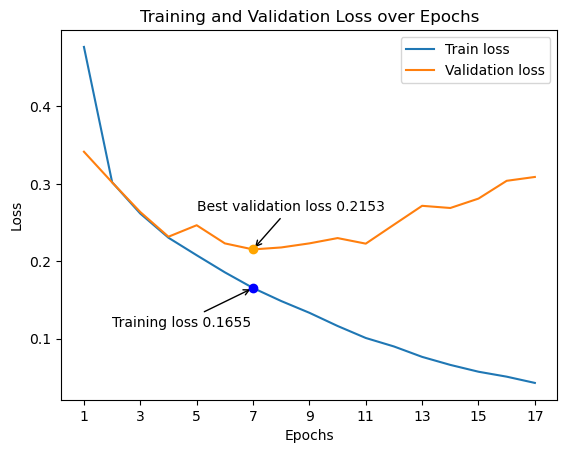

In [70]:
epochs = [i for i in range(1, curr_epoch+1)]
xticks = []
for i in epochs:
    if (i+1)%2==0:
        xticks.append(i)
        
plt.plot(epochs, train_avg_losses)
plt.plot(epochs, val_avg_losses)

# annotate train_loss
plt.scatter(selected_epoch, train_loss, color='blue', zorder=5)
plt.annotate(
    f'Training loss {train_loss:.4f}',
    xy=(selected_epoch, train_loss),
    xytext=(selected_epoch-5, train_loss-0.05),
    arrowprops=dict(arrowstyle='->')
)

# annotate val_loss
plt.scatter(selected_epoch, best_val_loss, color='orange', zorder=5)
plt.annotate(
    f'Best validation loss {best_val_loss:.4f}',
    xy=(selected_epoch, best_val_loss),
    xytext=(selected_epoch-2, best_val_loss+0.05),
    arrowprops=dict(arrowstyle='->')
)
plt.xticks(xticks, xticks)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train loss", "Validation loss"])
plt.title("Training and Validation Loss over Epochs")
plt.show()

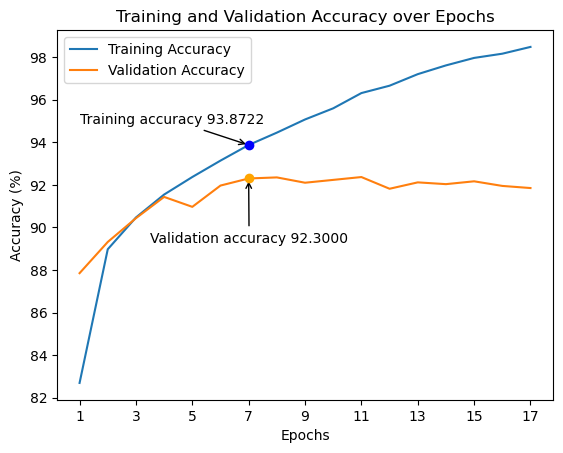

In [ ]:
plt.plot(epochs, train_accs)
plt.plot(epochs, val_accs)

# annotate train_acc
plt.scatter(selected_epoch, train_acc, color='blue', zorder=5)
plt.annotate(
    f'Training accuracy {train_acc:.4f}%',
    xy=(selected_epoch, train_acc),
    xytext=(selected_epoch-6, train_acc+1),
    arrowprops=dict(arrowstyle='->')
)

# annotate val_loss
plt.scatter(selected_epoch, val_acc, color='orange', zorder=5)
plt.annotate(
    f'Validation accuracy {val_acc:.4f}%',
    xy=(selected_epoch, val_acc),
    xytext=(selected_epoch-3.5, val_acc-3),
    arrowprops=dict(arrowstyle='->')
)
plt.xticks(xticks, xticks)
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.title("Training and Validation Accuracy over Epochs")
plt.show()

In [ ]:
best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.float()
        output = best_model(images)
        predictions = torch.argmax(output, dim=1)
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
acc_score = accuracy_score(all_labels, all_preds)*100
conf_matrix = confusion_matrix(all_labels, all_preds, )
class_report = classification_report(all_labels, all_preds)
print(f"Test Accuracy:{acc_score}%")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Per-class metrics:\n{class_report}")

Test Accuracy:91.73%
Confusion Matrix:
[[916   0  20  17   1   1  36   0   9   0]
 [  3 984   0  10   2   0   0   0   1   0]
 [ 20   0 899   8  35   1  37   0   0   0]
 [ 15   3  10 943  15   0  12   0   2   0]
 [  2   1  62  26 865   0  41   0   3   0]
 [  0   0   0   0   0 984   0  14   0   2]
 [153   1  76  31  71   0 658   0  10   0]
 [  0   0   0   0   0   5   0 978   0  17]
 [  2   1   0   5   0   2   0   4 986   0]
 [  1   0   0   0   0   7   0  32   0 960]]
Per-class metrics:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1000
           1       0.99      0.98      0.99      1000
           2       0.84      0.90      0.87      1000
           3       0.91      0.94      0.92      1000
           4       0.87      0.86      0.87      1000
           5       0.98      0.98      0.98      1000
           6       0.84      0.66      0.74      1000
           7       0.95      0.98      0.96      1000
           8       0.98 

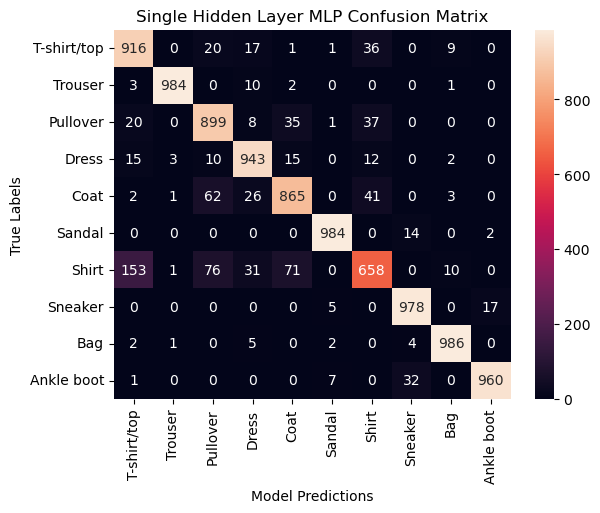

In [ ]:
sns.heatmap(conf_matrix, annot=True, fmt='d', 
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel('Model Predictions')
plt.ylabel('True Labels')
plt.title('CNN Confusion Matrix')
plt.show()

In [82]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),       # flip image horizontally
    transforms.RandomRotation(10),           # rotate ±10 degrees
    transforms.RandomCrop(28, padding=4),    # crop with padding
    transforms.ToTensor(),
])

augmented_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

In [83]:
# Reserve 10% of training set as validation (as per your assignment)
val_size = int(0.1 * len(augmented_train_dataset))
train_size = len(augmented_train_dataset) - val_size
train_data, val_data = random_split(augmented_train_dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
model = CustomCNN().float().to(device)

# hyper params
lr = 0.001
weight_decay=0.01
optim = torch.optim.AdamW(model.parameters(), lr, weight_decay=weight_decay)
loss = nn.CrossEntropyLoss()
patience = 10

# statistics to save
train_avg_losses = []
train_accs = []

val_avg_losses = []
val_accs = []

# variables for training
curr_epoch = 1
best_val_loss = float('inf')
best_model = model
patience_counter = 0
while True:
    print(f"---- Epoch {curr_epoch} ----")
    model.train()
    train_loss = 0
    train_total = 0
    train_correct = 0
    for images, labels in train_loader:
        # transfer data to the compute device
        images, labels = images.to(device), labels.to(device)
        images, labels = images.float(), labels.long()
        # perform predictions
        output = model(images)
        l = loss(output, labels)
        
        # store data
        predictions = torch.argmax(output, dim=1)
        train_loss += l.item()
        train_total += labels.size(0) # keep track of the total dataset since you don't know the size of the last batch
        train_correct += (predictions == labels).sum().item()
        
        # apply backpropagtion
        optim.zero_grad()
        l.backward()
        optim.step()
    
    train_avg_losses.append(train_loss/len(train_loader))
    train_accs.append((train_correct/train_total)*100)

    print(f"Avg training loss: {train_avg_losses[-1]:.4f}")
    print(f"Training accuracy: {train_accs[-1]:.4f}%")

    val_loss = 0
    val_total = 0
    val_correct = 0
    model.eval()
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        images, labels = images.float(), labels.long()

        output = model(images)

        l = loss(output, labels)

        predictions = torch.argmax(output, dim=1)
        val_loss += l.item()
        val_total += labels.size(0)
        val_correct += (predictions == labels).sum().item()
    
    val_avg_losses.append(val_loss/len(val_loader))
    val_accs.append((val_correct/val_total)*100)

    print(f"Avg validation loss: {val_avg_losses[-1]:.4f}")
    print(f"Validation accuracy: {val_accs[-1]:.4f}%")
    
    if val_avg_losses[-1] < best_val_loss:
        best_val_loss = val_avg_losses[-1]
        best_model = copy.deepcopy(model)
        patience_counter = 0
    else:
        patience_counter += 1
    
    print(f"Patience counter: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"Early stopping as patience counter has reached max value.")
        break
    curr_epoch += 1


---- Epoch 1 ----
Avg training loss: 0.4646
Training accuracy: 83.1481%
Avg validation loss: 0.3341
Validation accuracy: 88.1167%
Patience counter: 0/10
---- Epoch 2 ----
Avg training loss: 0.2981
Training accuracy: 89.1370%
Avg validation loss: 0.2865
Validation accuracy: 89.6167%
Patience counter: 0/10
---- Epoch 3 ----
Avg training loss: 0.2531
Training accuracy: 90.7130%
Avg validation loss: 0.2778
Validation accuracy: 89.9500%
Patience counter: 0/10
---- Epoch 4 ----
Avg training loss: 0.2217
Training accuracy: 91.8037%
Avg validation loss: 0.2539
Validation accuracy: 90.7167%
Patience counter: 0/10
---- Epoch 5 ----
Avg training loss: 0.1976
Training accuracy: 92.7389%
Avg validation loss: 0.2537
Validation accuracy: 90.6167%
Patience counter: 0/10
---- Epoch 6 ----
Avg training loss: 0.1810
Training accuracy: 93.2167%
Avg validation loss: 0.2190
Validation accuracy: 92.0500%
Patience counter: 0/10
---- Epoch 7 ----
Avg training loss: 0.1598
Training accuracy: 94.0241%
Avg valida